In [1]:
from sklearn.datasets import fetch_openml #importando o open ML
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report, cohen_kappa_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [2]:
dados = fetch_openml(data_id=1523) #ou url_spine = "https://raw.githubusercontent.com/JulianaMoretto/Postech-data-analytics/refs/heads/main/Machine-Learning/Dataset_spine.csv"
## link https://www.openml.org/d/1523
tabela_dados  = pd.DataFrame(data=dados['data'])
tabela_dados .head()

,V1,V2,V3,V4,V5,V6
0,63.027818,22.552586,39.609117,40.475232,98.672917,-0.254400
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259
2,68.832021,22.218482,50.092194,46.613539,105.985136,-3.530317
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501


In [3]:
type(dados)

sklearn.utils._bunch.Bunch

In [4]:
dados

{'data':             V1         V2         V3         V4          V5         V6
 0    63.027818  22.552586  39.609117  40.475232   98.672917  -0.254400
 1    39.056951  10.060991  25.015378  28.995960  114.405425   4.564259
 2    68.832021  22.218482  50.092194  46.613539  105.985136  -3.530317
 3    69.297008  24.652878  44.311238  44.644130  101.868495  11.211523
 4    49.712859   9.652075  28.317406  40.060784  108.168725   7.918501
 ..         ...        ...        ...        ...         ...        ...
 305  47.903565  13.616688  36.000000  34.286877  117.449062  -4.245395
 306  53.936748  20.721496  29.220534  33.215251  114.365845  -0.421010
 307  61.446597  22.694968  46.170347  38.751628  125.670725  -2.707880
 308  45.252792   8.693157  41.583126  36.559635  118.545842   0.214750
 309  33.841641   5.073991  36.641233  28.767649  123.945244  -0.199249
 
 [310 rows x 6 columns],
 'target': 0      1
 1      1
 2      1
 3      1
 4      1
       ..
 305    2
 306    2
 307    2
 

In [5]:
classes = {'1':'Disk Hernia',
           '2':'Normal',
           '3':'Spondylolisthesis'}

In [6]:
classes['1'], classes['2'], classes['3']

('Disk Hernia', 'Normal', 'Spondylolisthesis')

In [7]:
tabela_dados['diagnostic'] = [classes[target] for target in dados.target]

In [8]:
tabela_dados.head()

,V1,V2,V3,V4,V5,V6,diagnostic
0,63.027818,22.552586,39.609117,40.475232,98.672917,-0.254400,Disk Hernia
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Disk Hernia
2,68.832021,22.218482,50.092194,46.613539,105.985136,-3.530317,Disk Hernia
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,Disk Hernia
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Disk Hernia


In [9]:
tabela_dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   V1          310 non-null    float64
 1   V2          310 non-null    float64
 2   V3          310 non-null    float64
 3   V4          310 non-null    float64
 4   V5          310 non-null    float64
 5   V6          310 non-null    float64
 6   diagnostic  310 non-null    object 
dtypes: float64(6), object(1)
memory usage: 17.1+ KB


In [10]:
len(tabela_dados)

310

In [11]:
tabela_dados.describe()

,V1,V2,V3,V4,V5,V6
count,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000
mean,60.496653,17.542822,51.930930,42.953831,117.920655,26.296694
std,17.236520,10.008330,18.554064,13.423102,13.317377,37.559027
min,26.147921,-6.554948,14.000000,13.366931,70.082575,-11.058179
25%,46.430294,10.667069,37.000000,33.347122,110.709196,1.603727
50%,58.691038,16.357689,49.562398,42.404912,118.268178,11.767933
75%,72.877696,22.120395,63.000000,52.695889,125.467675,41.287352
max,129.834041,49.431864,125.742386,121.429566,163.071041,418.543082


In [12]:
tabela_dados.groupby('diagnostic').mean()

,V1,V2,V3,V4,V5,V6
diagnostic,,,,,,
Disk Hernia,47.638407,17.398795,35.463524,30.239612,116.474968,2.480251
Normal,51.685244,12.821414,43.542605,38.863830,123.890834,2.186572
Spondylolisthesis,71.514224,20.748038,64.110108,50.766186,114.518810,51.896687


In [13]:
tabela_dados.groupby('diagnostic').describe().T

diagnostic  Disk Hernia      Normal  Spondylolisthesis
V1 count      60.000000  100.000000         150.000000
   mean       47.638407   51.685244          71.514224
   std        10.697131   12.368161          15.109337
   min        26.147921   30.741938          37.903910
   25%        41.018099   42.817849          60.658136
   50%        46.416169   50.123115          72.149306
   75%        53.922329   61.470097          81.075893
   max        74.433593   89.834676         129.834041
V2 count      60.000000  100.000000         150.000000
   mean       17.398795   12.821414          20.748038
   std         7.016708    6.778503          11.506169
   min         3.144669   -5.845994          -6.554948
   25%        12.874329    8.799951          13.461149
   50%        16.949285   13.482435          19.309548
   75%        22.002981   16.785953          29.229680
   max        41.557331   29.894119          49.431864
V3 count      60.000000  100.000000         150.000000
   mean       35.463524   43.542605          64.110108
   std         9.767795   12.361388          16.397068
   min        14.000000   19.071075          24.710274
   25%        29.038069   35.000000          52.000000
   50%        35.164873   42.638923          62.555200
   75%        42.011563   51.602345          76.990924
   max        62.275275   90.563461         125.742386
V4 count      60.000000  100.000000         150.000000
   mean       30.239612   38.863830          50.766186
   std         7.555388    9.624004          12.318813
   min        13.366931   17.386972          19.290046
   25%        25.215274   32.340486          43.166815
   50%        30.000659   37.059694          50.751695
   75%        34.962103   44.608788          56.675435
   max        46.613539   67.195460         121.429566
V5 count      60.000000  100.000000         150.000000
   mean      116.474968  123.890834         114.518810
   std         9.355720    9.014246          15.579995
   min        84.241415  100.501192          70.082575
   25%       112.280320  118.182659         104.706761
   50%       116.696146  123.874329         114.842400
   75%       122.042999  129.040402         123.337307
   max       137.540613  147.894637         163.071041
V6 count      60.000000  100.000000         150.000000
   mean        2.480251    2.186572          51.896687
   std         5.531177    6.307483          40.108030
   min       -10.675871  -11.058179           1.010041
   25%        -0.910818   -1.511360          30.393271
   50%         2.542441    1.152710          42.372509
   75%         6.059666    4.968807          61.894425
   max        15.779697   31.172767         418.543082

Análise de quais linhas o V6 é maior do que 400, pois vemos que o máximo do V6 é 400, muito fora da média dele, mostrando um outlier.

In [14]:
tabela_dados.loc[tabela_dados['V6'] > 400]

,V1,V2,V3,V4,V5,V6,diagnostic
115,129.834041,8.404475,48.384057,121.429566,107.690466,418.543082,Spondylolisthesis


In [15]:
tabela_dados.drop(tabela_dados.loc[tabela_dados['V6'] > 400].index, inplace=True)

In [16]:
tabela_dados.loc[tabela_dados['V6'] > 400]

,V1,V2,V3,V4,V5,V6,diagnostic


In [17]:
x = tabela_dados.drop(columns=['diagnostic'])
y = tabela_dados['diagnostic'] #O que eu quero prever. (Target)

In [18]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, stratify=y,random_state=42)

In [19]:
scaler = MinMaxScaler() #aprende o mínimo e máximo de cada feature, essas estatística só existem no x
# o y é o alvo
# MinMaxScaler transforma cada feature para o intervalo [0, 1]
scaler.fit(x_train) #aprende o valor mínimo e máximo apenas no treino, evitando vazamento de dados
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)
#aplica mesma escala no treino e teste, garante consistência entre os dados
# transform o train e test,pois ambos são transformados com os mesmos parâmetros,simula o cenário real

📌 Por que isso é essencial para KNN?

O KNN calcula distâncias.

Sem normalização, variáveis com escala maior dominam o cálculo.

In [20]:
modelo_classificador = KNeighborsClassifier(n_neighbors=3)
modelo_classificador.fit(x_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=3)

📌 KNN não aprende parâmetros, ele compara distâncias.

In [21]:
y_predito = modelo_classificador.predict(x_test_scaled)

In [22]:
tabela_dados.groupby('diagnostic').count()

,V1,V2,V3,V4,V5,V6
diagnostic,,,,,,
Disk Hernia,60,60,60,60,60,60
Normal,100,100,100,100,100,100
Spondylolisthesis,149,149,149,149,149,149


In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

<Figure size 1500x500 with 0 Axes>

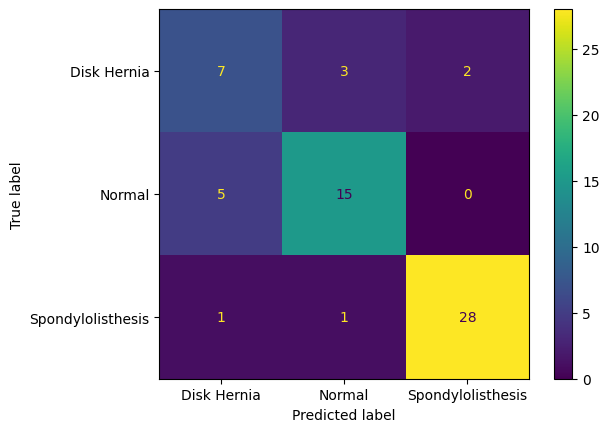

In [24]:
matriz_confusao = confusion_matrix(y_true = y_test,
                                   y_pred = y_predito,
                                   labels=['Disk Hernia', 'Normal', 'Spondylolisthesis'])

# plotando uma figura com a matriz de confusao
figure = plt.figure(figsize=(15, 5))
disp = ConfusionMatrixDisplay(confusion_matrix = matriz_confusao,
                              display_labels=['Disk Hernia', 'Normal', 'Spondylolisthesis'])
disp.plot(values_format='d')

In [25]:
print(classification_report(y_test, y_predito))

                   precision    recall  f1-score   support

      Disk Hernia       0.54      0.58      0.56        12
           Normal       0.79      0.75      0.77        20
Spondylolisthesis       0.93      0.93      0.93        30

         accuracy                           0.81        62
        macro avg       0.75      0.76      0.75        62
     weighted avg       0.81      0.81      0.81        62



**Precision** quando o modelo prevê uma classe, com que frequência acerta

**Recall** quantos casos reais daquela classe o modelo consegue identificar

**F1-score** equilíbrio entre precision e recall

**Spondylolisthesis** Excelente desempenho (F1 = 0.93)

**Normal** Bom desempenho (F1 = 0.77)

**Disk Hernia** Classe mais difícil (F1 = 0.56)

In [26]:
from sklearn.metrics import accuracy_score

In [27]:
print(round(accuracy_score(y_test, y_predito),2))

0.81


Testando o KNN com validação cruzada:

In [28]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

Objetivo: Avaliar a estabilidade e capacidade de generalização do KNN sem depender de uma única divisão treino/teste.

O que acontece aqui
* O dataset inteiro (x, y) é dividido em 5 partes
* Em cada rodada:
* 4 partes → treino
* 1 parte → validação

O processo se repete 5 vezes, trocando o fold de validação

In [29]:
kfold = KFold(n_splits=5, shuffle=True)
result = cross_val_score(modelo_classificador, x, y, cv = kfold)
print("K-Fold (R^2) Scores: {0}".format(result))
print("Mean R^2 for Cross-Validation K-Fold: {0}".format(result.mean()))

K-Fold (R^2) Scores: [0.87096774 0.74193548 0.85483871 0.79032258 0.81967213]
Mean R^2 for Cross-Validation K-Fold: 0.8155473294553147


👉 Isso indica que o modelo:

Não depende fortemente de uma única divisão

Tem desempenho consistente

A acurácia média (~83%) é mais confiável que um único teste

In [30]:
from sklearn.model_selection import GridSearchCV #metodo para seleção dos melhores Ks (#Basicamente a busca por força bruta)
from sklearn.metrics import make_scorer, accuracy_score, f1_score #métricas de validação
import numpy as np
import matplotlib.pyplot as plt

In [31]:
error = [] #armazenar os erros

# Calculating error for K values between 1 and 15
for i in range(1, 15):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train_scaled, y_train)
    pred_i = knn.predict(x_test_scaled)
    error.append(np.mean(pred_i != y_test))

O que você fez

* Testou valores de K de 1 a 14
* Calculou o erro médio para cada K
* Plotou erro × K

Interpretação do gráfico
* K pequeno → modelo muito sensível (overfitting)
* K grande → modelo muito genérico (underfitting)
* O melhor K é onde o erro é mínimo e estável

👉 Esse gráfico orienta a faixa de K, não a escolha final.

Text(0, 0.5, 'Mean Error')

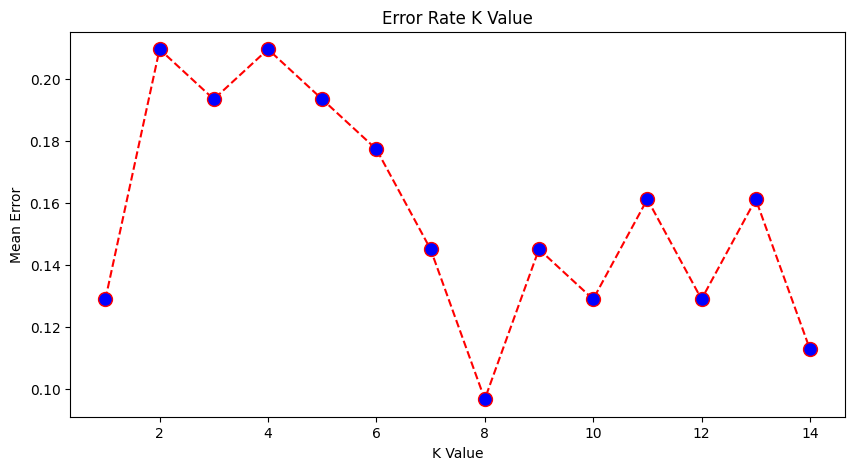

In [32]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 15), error, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=10)
plt.title('Error Rate K Value')
plt.xlabel('K Value')
plt.ylabel('Mean Error')

In [33]:
# Buscar os melhores parâmetros
# Vamos usar uma técnica chamada Gridsearch que é basicamente a busca por força bruta
# Iremos utilizar a técnica de validação cruzada de 5 folds (divisões) em cima do conjunto de treinamento
# Como métrica de melhor desemepnho usaremos a acurácia, isto é, estamos buscando os hiperparâmetros que maximizam a acurácia

# Parâmetros testados
param_grid = {'n_neighbors':[8,14], #total de vizinhos
              'weights': ['uniform', 'distance'], #Função de peso usada na previsão
              'metric':['cosine', 'euclidean', 'manhattan'] #métrica para cálculo da distância
             }

# Métrica de desempenho = melhor acurácia
gs_metric = make_scorer(accuracy_score, greater_is_better=True)

grid = GridSearchCV(KNeighborsClassifier(),
                    param_grid=param_grid,
                    scoring=gs_metric,
                    cv=5, n_jobs=4, verbose=3) #cv = gerador de validação cruzada / n_jobs = determina a quantidade de jobs processados

grid.fit(x_train_scaled, y_train) #Selecionando os melhores hiperparametros com base nos dados de treino
knn_params = grid.best_params_
print('KNN', knn_params)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
KNN {'metric': 'euclidean', 'n_neighbors': 8, 'weights': 'distance'}


Total de combinações (param_grid)

* 2 × 2 × 3 = 12 modelos
* Cada um avaliado com 5 folds
* Total: 60 treinos

In [34]:
knn_params

{'metric': 'euclidean', 'n_neighbors': 8, 'weights': 'distance'}

Interpretação

* Euclidean: distância padrão, funciona bem com dados normalizados
* weights='distance': vizinhos mais próximos têm mais peso
* K = 8: bom equilíbrio viés × variância

In [35]:
grid.cv_results_

{'mean_fit_time': array([0.00728989, 0.00641103, 0.00520058, 0.01036878, 0.00289941,
        0.00498428, 0.00599656, 0.00529118, 0.00750685, 0.00561724,
        0.00941863, 0.00957022]),
 'std_fit_time': array([0.00142439, 0.00151391, 0.00266176, 0.00283243, 0.00084691,
        0.00046874, 0.00266124, 0.00152749, 0.00144286, 0.00118374,
        0.00348007, 0.00365823]),
 'mean_score_time': array([0.01982446, 0.01012535, 0.01104236, 0.01412969, 0.00696483,
        0.00659699, 0.01083097, 0.00834842, 0.00948668, 0.00912194,
        0.01887975, 0.01314278]),
 'std_score_time': array([0.00678912, 0.00108532, 0.00317752, 0.00513345, 0.00320983,
        0.00062088, 0.00272591, 0.00119133, 0.00150174, 0.00403206,
        0.0017313 , 0.00287879]),
 'param_metric': masked_array(data=['cosine', 'cosine', 'cosine', 'cosine', 'euclidean',
                    'euclidean', 'euclidean', 'euclidean', 'manhattan',
                    'manhattan', 'manhattan', 'manhattan'],
              mask=[False, Fa

In [44]:
def AplicaValidacaoCruzada(x_axis, y_axis):
  # Linear Models.
  from sklearn.neighbors import KNeighborsClassifier  # k-vizinhos mais próximos (KNN)
  from sklearn.ensemble import RandomForestClassifier # RandomForest
  from sklearn.svm import SVC                         # Maquina de Vetor Suporte SVM

  # Cross-Validation models.
  from sklearn.model_selection import cross_val_score
  from sklearn.model_selection import KFold

  # Configuração de KFold.
  kfold  = KFold(n_splits=10, shuffle=True)

  # Axis
  x = x_axis
  y = y_axis

  # Criando os modelos

  # KNN
  knn = KNeighborsClassifier(n_neighbors=8, metric= 'euclidean', weights='distance')
  knn.fit(x, y)

  # SVM
  svm = SVC()
  svm.fit(x, y)

  # RandomForest
  rf = RandomForestClassifier(random_state=7)
  rf.fit(x, y)

  # Applyes KFold to models.
  knn_result = cross_val_score(knn, x, y, cv = kfold)
  svm_result = cross_val_score(svm, x, y, cv = kfold)
  rf_result = cross_val_score(rf, x, y, cv = kfold)

  # Creates a dictionary to store Linear Models.
  dic_models = {
    "KNN": knn_result.mean(),
    "SVM": svm_result.mean(),
    "RF": rf_result.mean()
  }

  # Select the best model.
  melhorModelo = max(dic_models, key=dic_models.get)

  print("KNN (R^2): {0}\nSVM (R^2): {1}\nRandom Forest (R^2): {2}".format(knn_result.mean(), svm_result.mean(), rf_result.mean()))
  print("O melhor modelo é : {0} com o valor: {1}".format(melhorModelo, dic_models[melhorModelo]))
  print("knn_result:", knn_result)
  print("svm_result:", svm_result)
  print("rf_result:", rf_result)

In [45]:
AplicaValidacaoCruzada(x, y)

KNN (R^2): 0.8674193548387097
SVM (R^2): 0.8544086021505375
Random Forest (R^2): 0.8253763440860216
O melhor modelo é : KNN com o valor: 0.8674193548387097
knn_result: [0.87096774 0.87096774 0.87096774 0.80645161 0.90322581 0.93548387
 0.83870968 0.80645161 0.87096774 0.9       ]
svm_result: [0.83870968 0.83870968 0.80645161 0.87096774 0.93548387 0.77419355
 0.83870968 0.90322581 0.87096774 0.86666667]
rf_result: [0.83870968 0.90322581 0.80645161 0.80645161 0.80645161 0.77419355
 0.74193548 0.87096774 0.83870968 0.86666667]
